### Setup base model and data

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import os

from ablation_utils.uncertainty import (
    UncertaintyData, ProbabilityEnsemble,
    ConstantEU, EntropyEU, VarianceEU, KNNRadius, MMIUncertainty, conformal_pvalues_loo
)
from sklearn.linear_model import LogisticRegression

os.makedirs("plots", exist_ok=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [108]:
# Leave exactly one `data = ...` block uncommented. Nothing below the rule moves.

from ablation_utils.data import blobs, pendigits, fashion_mnist

data = pendigits(eu_classes=(5, 6, 7, 8, 9), eu_keep=0.25, seed=0)
dataname="PENDIGITS"
#data = blobs(eu_classes=(5, 6, 7, 8), eu_keep=0.1, seed=0)
#dataname="BLOBS"
#data = fashion_mnist(eu_keep=0.3, seed=0)
#dataname="FASHION_MNIST"


X_train, y_train = data.X_train, data.y_train
X_calib, y_calib = data.X_calib, data.y_calib
X_test,  y_test  = data.X_test,  data.y_test

num_classes = data.num_classes
n_calib     = data.n_calib
group_test   = data.group_test      # readout key: size / coverage per cell

print(data.summary())

pendigits: K = 10, n_train = 3785, n_calib = 1000, n_test = 3000
  eu classes     [5, 6, 7, 8, 9]
  train / class  [612, 614, 635, 564, 622, 146, 143, 163, 144, 142]
  rest   train   3047   test   1572
  eu     train    738   test   1428


In [109]:
# model = RandomForestClassifier(n_estimators=100, max_iter=1000)
# model.fit(X_train, y_train)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# adjust max_depth to make model more or less capable
# 6 used for blobs and digits data
model = ProbabilityEnsemble(DecisionTreeClassifier(max_depth=6), k=25)

#for fashion mnist
#model = ProbabilityEnsemble(LogisticRegression(), k=25)
model.fit(X_train, y_train)

def scores_all(Xa):
    """(m, K) matrix of S(x, y) for every candidate label y."""
    return 1.0 - model.predict_proba(Xa)

S_calib_all = scores_all(X_calib)                    # (n_calib, K)
S_calib = S_calib_all[np.arange(n_calib), y_calib]   # (n_calib,)
S_test_all = scores_all(X_test)
S_test  = S_test_all[np.arange(len(X_test)), y_test]
acc = model.score(X_train, y_train)

print("base model accuracy (calib):", (model.predict(X_calib) == y_calib).mean())

base model accuracy (calib): 0.887


### Training a model of coverage levels

In [110]:
# set up for ablation - determine uncertainty methods to use
uncertainty_methods = {
    "constant": ConstantEU(),
  #  "entropy":  EntropyEU(model),
  #  "variance": VarianceEU(model),
  #  "knn":      KNNRadius(n_neighbors=25),
    "mmi_tv":   MMIUncertainty(form="tv"),
    "mmi_pi":   MMIUncertainty(form="pi"),
    "mmi_tv_evals":   MMIUncertainty(form="tv", evals=True),
    "mmi_pi_evals":   MMIUncertainty(form="pi", evals=True),
}

In [111]:
# construct the loo data needed for all uncertainty methods

n_loo = n_calib - 1
Sigma_loo = S_calib.sum() - S_calib                
E_loo = (n_loo + 1) * S_calib_all / (Sigma_loo[:, None] + S_calib_all)   
feats_loo = np.concatenate([Sigma_loo[:, None], np.sort(S_calib_all, axis=1)], axis=1)
P_loo     = conformal_pvalues_loo(S_calib, S_calib_all)


In [112]:
# bundle the calibration data
train_data = UncertaintyData(X=X_train)
calib_data = UncertaintyData(X=X_calib, E=E_loo, S=S_calib_all, P=P_loo)

for method in uncertainty_methods.values():
    method.fit(train_data).calibrate(calib_data)


In [113]:
import ablation_utils.neural_net as anet

# ablation config
train_loaders = {
    name: anet.make_loader(
        Sigma = Sigma_loo,
        S     = S_calib_all,
        E     = E_loo,
        u     = method.transform_loo(calib_data),
        batch_size = 32,
    )
    for name, method in uncertainty_methods.items()
}
# optimal lam changes with dataset
num_runs, num_epochs, lr = 4, 200, 1e-3

In [114]:
print(f"highest recommended lambda: {(num_classes-1) * E_loo.max()}")
lam=int(((num_classes-1) * E_loo.max())//5)*5

highest recommended lambda: 45.466950787198016


In [ ]:

# # Uncomment this cell to find a good value of lam for a new dataset. The value of lam is the regularization parameter for the alpha net. Lambdas too high will collapse to alpha=0. Lambdas too low will produce empty sets.
# # highest value here should be based on highest recommended lambda
# lambdas = [5, 10, 30, 60]

# lam_results = anet.multi_lambda_run_train_alpha_net(
#     train_loaders["constant"], lambdas,
#     num_epochs=100, lr=lr, num_runs=1, device=device, 
# )

# print(f"K = {num_classes}, n_calib = {n_calib}, alpha floor = {1/(n_calib+1):.4f}")
# for lam in lambdas:
#     a = lam_results[lam]["alphas"][:, -1]
#     s = lam_results[lam]["sizes"][:, -1]
#     print(f"  lambda {lam:>4}   alpha {a.mean():.3f} ± {a.std():.3f}"
#           f"   size {s.mean():.2f} ± {s.std():.2f}")


In [115]:

all_results = anet.run_uncertainty_ablation(
    train_loaders, lam=lam, num_epochs=num_epochs,
    lr=lr, num_runs=num_runs, device=device
)


[constant] run 1/4
  lam 45 | run 1 | epoch 0/200 | loss 26.7430 | size 2.0533 | alpha 0.5487
  lam 45 | run 1 | epoch 25/200 | loss 12.0137 | size 1.7602 | alpha 0.2279
  lam 45 | run 1 | epoch 50/200 | loss 12.0085 | size 1.7545 | alpha 0.2279
  lam 45 | run 1 | epoch 75/200 | loss 12.0077 | size 1.7360 | alpha 0.2283
  lam 45 | run 1 | epoch 100/200 | loss 12.0042 | size 1.7263 | alpha 0.2284
  lam 45 | run 1 | epoch 125/200 | loss 12.0012 | size 1.7254 | alpha 0.2284
  lam 45 | run 1 | epoch 150/200 | loss 11.9932 | size 1.7152 | alpha 0.2284
  lam 45 | run 1 | epoch 175/200 | loss 11.9899 | size 1.7163 | alpha 0.2283
  lam 45 | run 1 | epoch 199/200 | loss 11.9951 | size 1.7206 | alpha 0.2283

[constant] run 2/4
  lam 45 | run 2 | epoch 0/200 | loss 20.7199 | size 3.0488 | alpha 0.3927
  lam 45 | run 2 | epoch 25/200 | loss 12.0153 | size 1.7664 | alpha 0.2278
  lam 45 | run 2 | epoch 50/200 | loss 11.9976 | size 1.7376 | alpha 0.2280
  lam 45 | run 2 | epoch 75/200 | loss 11.996

c:\Users\User\Documents\learning-uncertainty-aware-policies\classification\neural_net.py:429: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


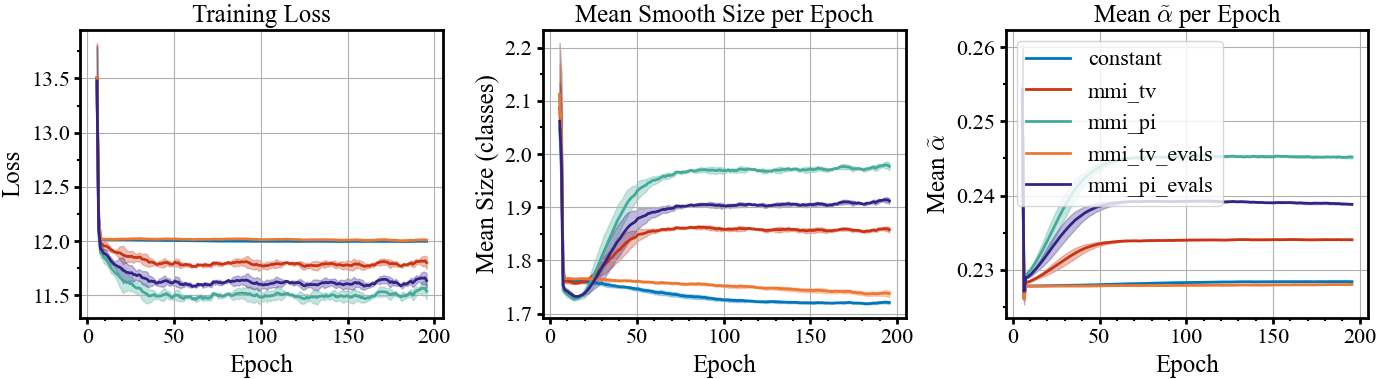

In [122]:
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import AutoMinorLocator
from tueplots import bundles

os.makedirs("plots", exist_ok=True)


anet.plot_performance(all_results, path=f"plots/alpha_net_results_uq_ablation_mmi_{dataname}_data.pdf")

### Learned coverage policy evaluation

In [123]:

def size_stratified_coverage(sizes, coverages, alphas, max_size=5):
    """
    Computes Size-Stratified Coverage (SSC) metrics, ignoring empty sets (size 0).
    
    Groups instances by prediction set size and calculates the empirical 
    coverage and nominal coverage (1 - alpha) within each size stratum.
    
    Parameters
    ----------
    sizes : array-like
        Cardinality (size) of prediction sets.
    coverages : array-like
        Binary coverage indicators (1 if covered, 0 otherwise).
    alphas : array-like
        Per-point miscoverage level targets (error rate).
    max_size : int, optional
        The maximum size threshold for grouping. Sizes >= max_size are 
        binned together to handle sparse tail samples. Default is 5.
        
    Returns
    -------
    ssc : float or None
        The formal SSC metric: the minimum empirical coverage observed 
        across any non-empty size strata (excluding size 0).
    worst_gap : float or None
        The most negative gap (empirical coverage - nominal coverage) observed,
        representing the worst-case localized undercoverage (excluding size 0).
    breakdown : dict
        A detailed mapping of each size stratum to its empirical coverage, 
        sample count, nominal coverage, and gap.
    """
    sizes = np.asarray(sizes, dtype=int)
    cov = np.asarray(coverages, dtype=float)
    alphas = np.asarray(alphas, dtype=float)
    
    # 1. Filter out empty prediction sets (size 0)
    non_empty_mask = (sizes > 0)
    sizes = sizes[non_empty_mask]
    cov = cov[non_empty_mask]
    alphas = alphas[non_empty_mask]
    
    # Safeguard if all prediction sets in the batch are empty
    if len(sizes) == 0:
        return None, None, {}
    
    # 2. Cap sizes at max_size to pool small sample counts in the tail
    binned_sizes_max = np.minimum(sizes, max_size)
    unique_bins = np.unique(binned_sizes_max)
    
    breakdown = {}
    valid_coverages = []
    gaps = []
    
    for b in unique_bins:
        idx = (binned_sizes_max == b)
        count = int(np.sum(idx))
        if count == 0:
            continue
            
        emp_cov = float(np.mean(cov[idx]))
        nominal_cov = float(np.mean(1.0 - alphas[idx]))
        gap = emp_cov - nominal_cov
        
        valid_coverages.append(emp_cov)
        gaps.append(gap)
        
        bin_label = f"size {b}" if b < max_size else f"size >={max_size}"
        breakdown[bin_label] = {
            "count": count,
            "empirical_coverage": emp_cov,
            "nominal_coverage": nominal_cov,
            "gap": gap
        }
        
    # The standard SSC is defined as the minimum coverage across all non-empty strata
    ssc = float(np.min(valid_coverages)) if valid_coverages else None
    worst_gap = float(np.min(gaps)) if gaps else None
    
    return ssc, worst_gap, breakdown

In [118]:
import numpy as np, pandas as pd, torch
from sklearn.neighbors import NearestNeighbors
from ablation_utils.uncertainty import UncertaintyData, conformal_pvalues
import ablation_utils.neural_net as anet

ALPHA_FIXED, Q_TAIL = 0.10, 0.10

Sigma_test = float(S_calib.sum())
E_test     = (n_calib + 1) * S_test_all / (Sigma_test + S_test_all)
test_data  = UncertaintyData(X=X_test, E=E_test, S=S_test_all,
                             P=conformal_pvalues(S_calib, S_test_all))

def aisl(sizes, coverages, alphas):
    """
    Discrete average interval score loss.

        AISL = (1/m) sum_i [ |C(X_i)| + (2/alpha_i) 1{Y_i not in C(X_i)} ]

    The published AISL measures width as max C - min C and penalises the
    distance by which the truth falls outside. Both need an ordered outcome;
    for nominal labels width becomes cardinality and the excursion term becomes
    an indicator. alpha_i is per-point, so an adaptive policy is scored against
    the level it actually promised that point.
    """
    sizes = np.asarray(sizes,     dtype=float)
    cov   = np.asarray(coverages, dtype=float)
    a     = np.clip(np.asarray(alphas, dtype=float), 1e-12, None)
    return float(np.mean(sizes + (2.0 / a) * (1.0 - cov)))

def set_metrics(coverages, sizes, alphas):
    cov     = float(np.mean(coverages))
    a_mean  = float(np.mean(alphas))
    nominal = 1.0 - a_mean
    ssc_val, worst_gap, ssc_breakdown = size_stratified_coverage(
        sizes, coverages, alphas
    )
    metrics = {
        "mean alpha":    a_mean,
        "nominal cov":   nominal,
        "coverage":      cov,
        "gap":           cov - nominal,        # < 0 means the global promise is broken
        "mean size":     float(np.mean(sizes)),
        "SSC":           ssc_val,              # Standard SSC: worst-case absolute coverage
        "worst SSC gap": worst_gap,            # Worst localized gap (empirical vs nominal)
        "% empty":       100.0 * np.mean(np.asarray(sizes) == 0),
    }
    return metrics

def aggregate(per_run):
    return {k: (np.mean([r[k] for r in per_run]), np.std([r[k] for r in per_run]))
            for k in per_run[0]}


rows, curves, sizes_for_hist = {}, {}, {}

# --- learned policies ---------------------------------------------------------
for name, method in uncertainty_methods.items():
    u_test  = method.transform_normalized(test_data)
    per_run = []
    for r, net in enumerate(all_results[name]["nets"]):
        cov, sz, a = anet.evaluate_adaptive(
            net, S_test_all, y_test, Sigma_test, u_test, n_calib, device=device)
        per_run.append(set_metrics(cov, sz, a))
        if r == 0:
            curves[name] = anet.reliability(cov, a)
            sizes_for_hist[name] = sz
    rows[name] = aggregate(per_run)

# --- non-adaptive baselines ---------------------------------------------------
# label = "fixed a (e-value)"
# cov, sz = anet.evaluate_standard(all_scores=S_test_all, all_y_test=y_test, cal_scores=S_calib,
               #                                                     alpha=ALPHA_FIXED, calibration_size=n_calib, num_classes=num_classes)
# a = np.full(len(S_test_all), float(ALPHA_FIXED))
# rows[label] = aggregate([set_metrics(cov, sz, a, outlyingness)])
# curves[label] = anet.reliability(cov, a)
# sizes_for_hist[label] = sz

# --- table --------------------------------------------------------------------
metrics = list(next(iter(rows.values())))
df_num  = pd.DataFrame({m: {k: rows[k][m][0] for k in rows} for m in metrics})
df_std  = pd.DataFrame({m: {k: rows[k][m][1] for k in rows} for m in metrics})
df_fmt  = df_num.round(3).astype(str) + " ± " + df_std.round(3).astype(str)

print(f"Test split, n = {len(X_test)}, K = {num_classes}, "
      f"baselines at alpha = {ALPHA_FIXED}")
print("gap = empirical coverage - (1 - mean alpha); negative means over-promised\n")
print(df_fmt.to_string())
print("\n" + df_num.round(3).to_latex())

Test split, n = 3000, K = 10, baselines at alpha = 0.1
gap = empirical coverage - (1 - mean alpha); negative means over-promised

                 mean alpha    nominal cov       coverage            gap      mean size            SSC   worst SSC gap    % empty
constant       0.23 ± 0.001   0.77 ± 0.001  0.955 ± 0.001    0.185 ± 0.0  1.272 ± 0.006      0.5 ± 0.0  -0.256 ± 0.001  0.0 ± 0.0
mmi_tv        0.235 ± 0.001  0.765 ± 0.001  0.969 ± 0.001  0.205 ± 0.001  1.458 ± 0.016   0.94 ± 0.008   0.155 ± 0.007  0.0 ± 0.0
mmi_pi        0.245 ± 0.001  0.755 ± 0.001  0.974 ± 0.001   0.22 ± 0.001  1.719 ± 0.011   0.95 ± 0.002   0.176 ± 0.001  0.0 ± 0.0
mmi_tv_evals   0.23 ± 0.001   0.77 ± 0.001  0.957 ± 0.001  0.187 ± 0.001  1.288 ± 0.007  0.646 ± 0.091   -0.115 ± 0.09  0.0 ± 0.0
mmi_pi_evals   0.24 ± 0.002   0.76 ± 0.002   0.97 ± 0.001   0.21 ± 0.001  1.538 ± 0.018  0.948 ± 0.003   0.164 ± 0.006  0.0 ± 0.0

\begin{tabular}{lrrrrrrrr}
\toprule
 & mean alpha & nominal cov & coverage & gap & mean s

In [124]:
rows, curves, sizes_for_hist = {}, {}, {}
raw = {}                                              

for name, method in uncertainty_methods.items():
    u_test  = method.transform_normalized(test_data)
    per_run, per_run_raw = [], []                     
    for r, net in enumerate(all_results[name]["nets"]):
        cov, sz, a = anet.evaluate_adaptive(
            net, S_test_all, y_test, Sigma_test, u_test, n_calib, device=device)
        per_run.append(set_metrics(cov, sz, a))
        per_run_raw.append((cov, sz, a))               
        if r == 0:
            curves[name] = anet.reliability(cov, a)
            sizes_for_hist[name] = sz
    rows[name] = aggregate(per_run)
    raw[name] = per_run_raw                                 



C:\Users\User\AppData\Local\Temp\ipykernel_28516\242127856.py:52: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


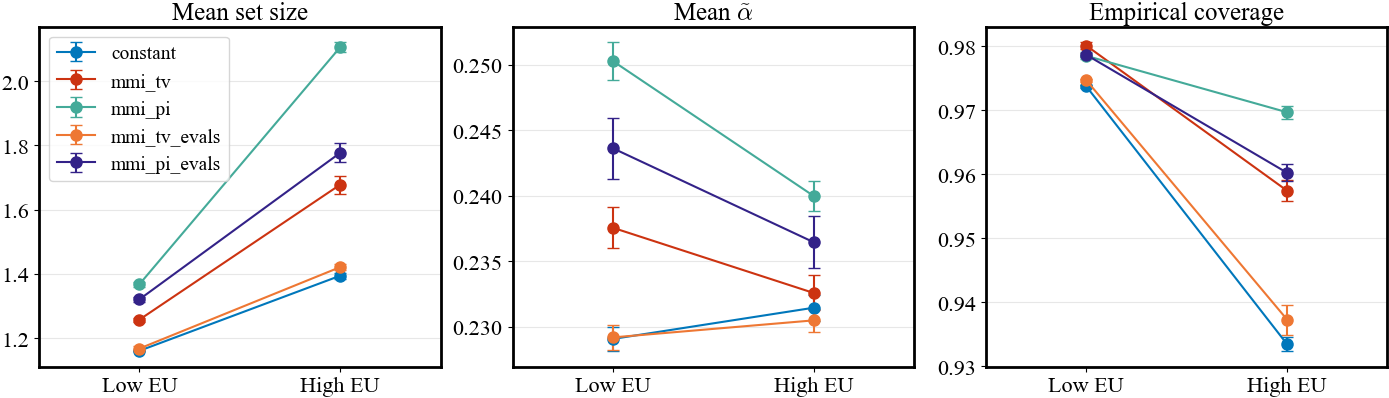

In [125]:
def to_np(v):
    return v.detach().cpu().numpy() if hasattr(v, "detach") else np.asarray(v)

GROUPS  = ["rest", "eu"]
LABEL   = {"rest": "Low EU", "eu": "High EU"}
METRICS = [("size",     "Mean set size"),
           ("alpha",    r"Mean $\tilde\alpha$"),
           ("coverage", "Empirical coverage")]

S_np   = to_np(S_test_all)
y_np   = to_np(y_test).astype(int)
g_np   = np.asarray(group_test)
groups = [g for g in GROUPS if (g_np == g).any()]
names  = list(raw)
colors = dict(zip(names, anet._PALETTE))

plt.rcParams.update(bundles.icml2024(usetex=False))
plt.rcParams.update({
    "axes.labelsize": 18, "axes.titlesize": 18,
    "xtick.labelsize": 16, "ytick.labelsize": 16,
    "legend.fontsize": 14, "lines.linewidth": 2, "axes.linewidth": 2,
})


def draw(ax, v, x, color, label):
    ax.errorbar(x, v.mean(axis=0), yerr=v.std(axis=0), color=color, label=label,
                marker="o", markersize=8, linewidth=1.5, capsize=4, elinewidth=1.5)


def style(ax, labels, title):
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_xlim(-0.5, len(labels) - 0.5)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_axisbelow(True)

def group_stats(cov, sz, a, m):
    cov, sz, a = (to_np(v).astype(float) for v in (cov, sz, a))
    return {"size": sz[m].mean(), "alpha": a[m].mean(), "coverage": cov[m].mean()}

stat = {n: {k: np.array([[group_stats(*run, g_np == g)[k] for g in groups] for run in raw[n]])
            for k, _ in METRICS}
        for n in names}

fig, axs = plt.subplots(1, len(METRICS), figsize=(4.7 * len(METRICS), 4.2))
for ax, (key, title) in zip(axs, METRICS):
    for n in names:
        draw(ax, stat[n][key], np.arange(len(groups)), colors[n], n)
    style(ax, [LABEL[g] for g in groups], title)
axs[0].legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.savefig(f"plots/groups_by_method_mmi_{dataname}_data.pdf", bbox_inches="tight")
plt.show()

In [128]:
# Class-wise MISCOVERAGE (1 - coverage)
# difficulty heuristic: mean true-class score on each class's test points
HIGHER_IS_HARDER = True          # True if S_np is a nonconformity score, False if it's a softmax prob

true_score = S_np[np.arange(len(y_np)), y_np]
classes    = np.unique(y_np)
order      = np.argsort([true_score[y_np == c].mean() for c in classes])
classes    = classes[order if HIGHER_IS_HARDER else order[::-1]]   # easy -> hard
k          = max(1, len(classes) // 3)
easy, hard = slice(0, k), slice(len(classes) - k, None)

cmis, marg = {}, {}
for n in names:
    covs    = [to_np(cov).astype(float) for cov, _, _ in raw[n]]
    cmis[n] = np.array([[1.0 - c[y_np == cl].mean() for cl in classes] for c in covs])
    marg[n] = np.array([1.0 - c.mean() for c in covs])

metrics = {n: {
    r"marginal miscov":  marg[n],
    r"max - min":        cmis[n].max(1) - cmis[n].min(1),
    r"max class miscov": cmis[n].max(1),
} for n in names}

def fmt(v, tex=False):
    return f"{v.mean():.3f} {'$\\pm$' if tex else '±'} {v.std():.3f}"

summary   = pd.DataFrame({n: {m: fmt(v)       for m, v in d.items()} for n, d in metrics.items()}).T
summary_x = pd.DataFrame({n: {m: fmt(v, True) for m, v in d.items()} for n, d in metrics.items()}).T
per_class = pd.DataFrame({n: cmis[n].mean(0) for n in names}, index=classes).T.round(3)
per_class.columns.name = "class (easy -> hard)"

print("Smaller max-min = miscoverage more uniform across classes\n")
print(summary.to_string(), "\n")
print("Class miscoverage, mean over runs")
print(per_class.to_string(), "\n")

latex = summary_x.to_latex(
    escape=False, column_format="l" + "r" * summary_x.shape[1],
    caption=r"Class-conditional miscoverage. Mean $\pm$ sd over runs; "
            r"easy/hard are the first and last thirds of classes ranked by "
            r"mean true-class score.",
    label="tab:class-miscoverage",
)
print(latex)

Smaller max-min = miscoverage more uniform across classes

             marginal miscov      max - min max class miscov
constant       0.045 ± 0.001  0.102 ± 0.000    0.108 ± 0.000
mmi_tv         0.031 ± 0.001  0.069 ± 0.005    0.069 ± 0.005
mmi_pi         0.026 ± 0.001  0.075 ± 0.001    0.076 ± 0.001
mmi_tv_evals   0.043 ± 0.001  0.101 ± 0.003    0.104 ± 0.003
mmi_pi_evals   0.030 ± 0.001  0.073 ± 0.000    0.073 ± 0.000 

Class miscoverage, mean over runs
class (easy -> hard)      0      4      6     3      2      1      8      7      5      9
constant              0.006  0.006  0.022  0.02  0.016  0.079  0.094  0.108  0.085  0.029
mmi_tv                0.006  0.000  0.015  0.01  0.015  0.065  0.055  0.062  0.069  0.014
mmi_pi                0.003  0.002  0.015  0.01  0.013  0.076  0.043  0.043  0.046  0.006
mmi_tv_evals          0.006  0.003  0.019  0.02  0.016  0.078  0.087  0.104  0.085  0.024
mmi_pi_evals          0.005  0.000  0.018  0.01  0.016  0.073  0.057  0.051  0.062  0.014

C:\Users\User\AppData\Local\Temp\ipykernel_28516\425001817.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


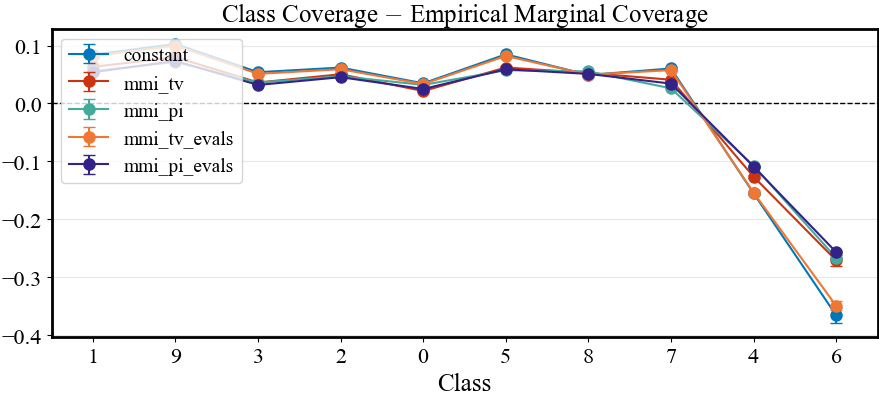

In [ ]:
# does miscoverage vary across classes
# flatter lines are better
fig, ax = plt.subplots(1, 1, figsize=(max(6, 0.9 * len(classes)), 4.2))
for n in names:
    draw(ax, (1.0 - cmis[n]) - (1.0 - marg[n])[:, None], np.arange(len(classes)), colors[n], n)

ax.axhline(0, color="k", linewidth=1, linestyle="--")
style(ax, [str(c) for c in classes], "Class Coverage $-$ Empirical Marginal Coverage")
ax.set_xlabel("Class")
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.savefig(f"plots/classwise_by_method_{dataname}_data.pdf", bbox_inches="tight")
plt.show()